# Fraud Detectation in Electricity & Gas Consumption Challenge

Neue Fische's Machine Learning Challenge based on the tutorial prepared by Joy Wawira. 
This machine learning project tackles a critical real-world problem: identifying fraudulent patterns in electricity and gas meter readings. Built on data from Zindi Africa's industry-sponsored competition, this implementation addresses financial losses, operational inefficiencies, and infrastructure integrity challenges faced by utility providers across emerging markets.
Check out the article [here](https://zindi.africa/learn/fraud-detection-in-electricity-and-gas-consumption-challenge-tutorial) for a more detailed description of the steps taken.

This notebook covers:
- Acquired the data from the source (Zindi)
- Loading the data and carrying out simple EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Model accuracy against interpretability for investivative teams
- Detection rates versus false positive operational costs
- Computational efficiency for near-real-time scoring
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv

In [4]:
# Import necessary libraries
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Path setup
CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parents[0]
DATA_DIR = ROOT_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
sys.path.insert(0, str(ROOT_DIR))

# Load data
client_train_df = pd.read_csv(TRAIN_DIR / "client_train.csv", low_memory=False)
invoice_train_df = pd.read_csv(TRAIN_DIR / "invoice_train.csv", low_memory=False)
client_test_df = pd.read_csv(TEST_DIR / "client_test.csv", low_memory=False)
invoice_test_df = pd.read_csv(TEST_DIR / "invoice_test.csv", low_memory=False)

In [17]:
# client_train data preview
client_train_df.head(2)

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0


In [18]:
# invoice_train data preview
invoice_train_df.head(2)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC


In [19]:
# client_test data preview
client_test_df.head(2)

,disrict,client_id,client_catg,region,creation_date
0,62,test_Client_0,11,307,28/05/2002
1,69,test_Client_1,11,103,06/08/2009


In [20]:
# invoice_ test data preview
invoice_test_df.head(2)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,test_Client_0,2018-03-16,11,651208,0,203,8,1,755,0,0,0,19145,19900,8,ELEC
1,test_Client_0,2014-03-21,11,651208,0,203,8,1,1067,0,0,0,13725,14792,8,ELEC


In [ ]:
# compare size of the various datasets
print(client_train_df.shape, invoice_train_df.shape, client_test_df.shape, invoice_train_df.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [23]:
# Numerical values in client_train data
client_train_df.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [24]:
# Numerical values in invoice train data
invoice_train_df.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [25]:
# Info on client_train data
client_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [26]:
# Info on invoice_train data
invoice_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [28]:
# Unique values on the invoice train data
for col in client_train_df.columns:
    print(f"{col} - {client_train_df[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2


In [27]:
# Unique values on the invoice train data
for col in invoice_train_df.columns:
    print(f"{col} - {invoice_train_df[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [29]:
# Dataset Summary
print("Dataset sizes:")
print(f"Train clients: {client_train_df.shape[0]:,}")
print(f"Train invoices: {invoice_train_df.shape[0]:,}")
print(f"Test clients: {client_test_df.shape[0]:,}")
print(f"Test invoices: {invoice_test_df.shape[0]:,}")

Dataset sizes:
Train clients: 135,493
Train invoices: 4,476,749
Test clients: 58,069
Test invoices: 1,939,730


In [30]:
# Checking for missing values
client_train_df.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [31]:
# Checking for missing values
invoice_train_df.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [37]:
client_features = invoice_train_df.groupby('client_id').agg({
    'consommation_level_1': 'mean',
    'consommation_level_2': 'mean',
    'consommation_level_3': 'mean',
    'consommation_level_4': 'mean',
    'invoice_date': ['count', 'min', 'max']  # Number of invoices
}).rename(columns={'invoice_date': 'invoice_count'})
client_features

consommation_level_1 consommation_level_2   
                                   mean                 mean   
client_id                                                      
train_Client_0               352.400000            10.571429  \
train_Client_1               557.540541             0.000000   
train_Client_10              798.611111            37.888889   
train_Client_100               1.200000             0.000000   
train_Client_1000            663.714286           104.857143   
...                                 ...                  ...   
train_Client_99995             1.957746             0.000000   
train_Client_99996           185.853659             0.756098   
train_Client_99997           273.083333             0.000000   
train_Client_99998           300.000000            70.500000   
train_Client_99999           459.333333             0.000000   

                   consommation_level_3 consommation_level_4 invoice_count   
                                   mean                 mean         count   
client_id                                                                    
train_Client_0                 0.000000             0.000000            35  \
train_Client_1                 0.000000             0.000000            37   
train_Client_10                0.000000             0.000000            18   
train_Client_100               0.000000             0.000000            20   
train_Client_1000            117.357143            36.714286            14   
...                                 ...                  ...           ...   
train_Client_99995             0.000000             0.000000            71   
train_Client_99996             0.000000             0.000000            41   
train_Client_99997             0.000000             0.000000            36   
train_Client_99998             0.000000             0.000000             2   
train_Client_99999             0.000000             0.000000             3   

                                            
                           min         max  
client_id                                   
train_Client_0      2005-10-17  2019-03-19  
train_Client_1      2005-10-19  2019-04-02  
train_Client_10     2005-11-10  2019-05-02  
train_Client_100    2005-06-10  2012-09-25  
train_Client_1000   2015-02-13  2019-06-17  
...                        ...         ...  
train_Client_99995  2005-07-10  2019-06-26  
train_Client_99996  2013-02-22  2019-06-18  
train_Client_99997  2012-02-15  2019-11-06  
train_Client_99998  2005-08-19  2005-12-19  
train_Client_99999  1996-01-25  1996-09-25  

[135493 rows x 7 columns]

In [38]:
client_features.columns

MultiIndex([('consommation_level_1',  'mean'),
            ('consommation_level_2',  'mean'),
            ('consommation_level_3',  'mean'),
            ('consommation_level_4',  'mean'),
            (       'invoice_count', 'count'),
            (       'invoice_count',   'min'),
            (       'invoice_count',   'max')],
           )

In [ ]:
client_features.columns = ['_'.join(col).strip() for col in client_features.columns.values]
client_features.columns


Index(['consommation_level_1_mean', 'consommation_level_2_mean',
       'consommation_level_3_mean', 'consommation_level_4_mean',
       'invoice_count_count', 'invoice_count_min', 'invoice_count_max'],
      dtype='object')

In [40]:
client_features

,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,invoice_count_count,invoice_count_min,invoice_count_max
client_id,,,,,,,
train_Client_0,352.400000,10.571429,0.000000,0.000000,35,2005-10-17,2019-03-19
train_Client_1,557.540541,0.000000,0.000000,0.000000,37,2005-10-19,2019-04-02
train_Client_10,798.611111,37.888889,0.000000,0.000000,18,2005-11-10,2019-05-02
train_Client_100,1.200000,0.000000,0.000000,0.000000,20,2005-06-10,2012-09-25
train_Client_1000,663.714286,104.857143,117.357143,36.714286,14,2015-02-13,2019-06-17
...,...,...,...,...,...,...,...
train_Client_99995,1.957746,0.000000,0.000000,0.000000,71,2005-07-10,2019-06-26
train_Client_99996,185.853659,0.756098,0.000000,0.000000,41,2013-02-22,2019-06-18
train_Client_99997,273.083333,0.000000,0.000000,0.000000,36,2012-02-15,2019-11-06


In [41]:
client_features.index

Index(['train_Client_0', 'train_Client_1', 'train_Client_10',
       'train_Client_100', 'train_Client_1000', 'train_Client_10000',
       'train_Client_100000', 'train_Client_100001', 'train_Client_100002',
       'train_Client_100003',
       ...
       'train_Client_99990', 'train_Client_99991', 'train_Client_99992',
       'train_Client_99993', 'train_Client_99994', 'train_Client_99995',
       'train_Client_99996', 'train_Client_99997', 'train_Client_99998',
       'train_Client_99999'],
      dtype='object', name='client_id', length=135493)

In [42]:
client_features.reset_index(inplace=True)

In [43]:
client_features.index

RangeIndex(start=0, stop=135493, step=1)

In [44]:
client_features

,client_id,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,invoice_count_count,invoice_count_min,invoice_count_max
0,train_Client_0,352.400000,10.571429,0.000000,0.000000,35,2005-10-17,2019-03-19
1,train_Client_1,557.540541,0.000000,0.000000,0.000000,37,2005-10-19,2019-04-02
2,train_Client_10,798.611111,37.888889,0.000000,0.000000,18,2005-11-10,2019-05-02
3,train_Client_100,1.200000,0.000000,0.000000,0.000000,20,2005-06-10,2012-09-25
4,train_Client_1000,663.714286,104.857143,117.357143,36.714286,14,2015-02-13,2019-06-17
...,...,...,...,...,...,...,...,...
135488,train_Client_99995,1.957746,0.000000,0.000000,0.000000,71,2005-07-10,2019-06-26
135489,train_Client_99996,185.853659,0.756098,0.000000,0.000000,41,2013-02-22,2019-06-18
135490,train_Client_99997,273.083333,0.000000,0.000000,0.000000,36,2012-02-15,2019-11-06
135491,train_Client_99998,300.000000,70.500000,0.000000,0.000000,2,2005-08-19,2005-12-19


In [45]:

print(f"Aggregated features for {len(client_features):,} clients")

# Merging with client data
merged_data = pd.merge(
    client_train_df,
    client_features,
    on='client_id',
    how='left'
)

print(f"\nClient-level merged data: {merged_data.shape}")
print(f"Rows: {len(merged_data):,} (1 per client)")
display(merged_data.head(3))

Aggregated features for 135,493 clients

Client-level merged data: (135493, 13)
Rows: 135,493 (1 per client)


,disrict,client_id,client_catg,region,creation_date,target,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,invoice_count_count,invoice_count_min,invoice_count_max
0,60,train_Client_0,11,101,31/12/1994,0.0,352.400000,10.571429,0.0,0.0,35,2005-10-17,2019-03-19
1,69,train_Client_1,11,107,29/05/2002,0.0,557.540541,0.000000,0.0,0.0,37,2005-10-19,2019-04-02
2,62,train_Client_10,11,301,13/03/1986,0.0,798.611111,37.888889,0.0,0.0,18,2005-11-10,2019-05-02


In [46]:
clean_data = merged_data.copy()

In [47]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   disrict                    135493 non-null  int64  
 1   client_id                  135493 non-null  object 
 2   client_catg                135493 non-null  int64  
 3   region                     135493 non-null  int64  
 4   creation_date              135493 non-null  object 
 5   target                     135493 non-null  float64
 6   consommation_level_1_mean  135493 non-null  float64
 7   consommation_level_2_mean  135493 non-null  float64
 8   consommation_level_3_mean  135493 non-null  float64
 9   consommation_level_4_mean  135493 non-null  float64
 10  invoice_count_count        135493 non-null  int64  
 11  invoice_count_min          135493 non-null  object 
 12  invoice_count_max          135493 non-null  object 
dtypes: float64(5), int64(4), obje

In [48]:
clean_data.describe()

,disrict,client_catg,region,target,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,invoice_count_count
count,135493.000000,135493.000000,135493.000000,135493.000000,135493.000000,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841,432.366021,115.334253,27.634241,73.097981,33.040445
std,3.354400,4.423761,104.207044,0.229614,758.003977,747.416809,157.294518,814.216626,26.092229
min,60.000000,11.000000,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,62.000000,11.000000,103.000000,0.000000,215.280702,0.000000,0.000000,0.000000,10.000000
50%,62.000000,11.000000,107.000000,0.000000,355.640625,4.987179,0.000000,0.000000,30.000000
75%,69.000000,11.000000,307.000000,0.000000,541.888889,63.636364,3.929825,0.000000,50.000000
max,69.000000,51.000000,399.000000,1.000000,99920.000000,115683.000000,38526.857143,79179.777778,439.000000


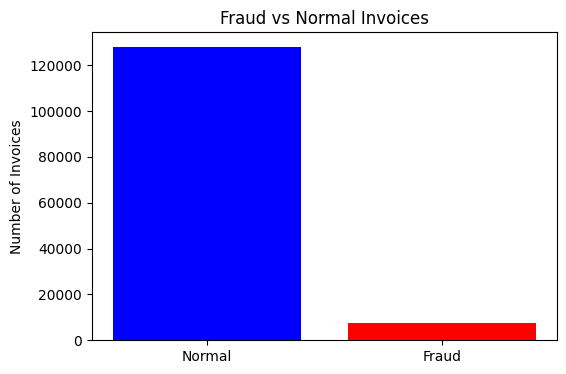

Normal: 127,927 invoices
Fraud: 7,566 invoices


In [49]:
# Visualising the normal vs fraudulant invoices
fraud_counts = clean_data['target'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Fraud'], fraud_counts.values, color=['blue', 'red'])
plt.title('Fraud vs Normal Invoices')
plt.ylabel('Number of Invoices')
plt.show()

print(f"Normal: {fraud_counts[0]:,} invoices")
print(f"Fraud: {fraud_counts[1]:,} invoices")